In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [130]:
# Функция Розенброка: f(x, y) = (a - x)^2 + b*(y - x^2)^2
def rosenbrock(x, y, a=1, b=2):
    return (a - x)**2 + b * (y - x**2)**2

# Градиент функции Розенброка
def rosenbrock_grad(x, y, a=1, b=2):
    dfdx = -2 * (a - x) - 4 * b * x * (y - x**2)
    dfdy = 2 * b * (y - x**2)
    return np.array([dfdx, dfdy])

In [131]:
def get_minimum_point(a):
    return np.array([a, a**2])

In [132]:
# 1. Градиентный метод с постоянным шагом
def gradient_descent_fixed(x0, alpha, eps, a, b, max_iter=10000):
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    for _ in range(max_iter):
        grad = rosenbrock_grad(x[0], x[1], a, b)
        x_new = x - alpha * grad
        trajectory.append(x_new.copy())
        if np.linalg.norm(x_new - x) < eps:
            break
        x = x_new
    return np.array(trajectory)


In [133]:
# Метод 2: с дроблением (алг.1)
def gradient_descent_splitting1(x0, a0, eps, a, b, max_iter=10000):
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    step_param = a0
    for _ in range(max_iter):
        grad = rosenbrock_grad(x[0], x[1], a, b)
        s = -grad
        alpha = step_param**2
        
        # Удваиваем
        while True:
            x_trial = x + alpha * s
            if rosenbrock(x_trial[0], x_trial[1], a, b) < rosenbrock(x[0], x[1], a, b):
                alpha *= 2
            else:
                break
        
        # Делим до убывания
        while True:
            x_trial = x + alpha * s
            if rosenbrock(x_trial[0], x_trial[1], a, b) >= rosenbrock(x[0], x[1], a, b):
                alpha /= 2
            else:
                break
        
        x_new = x + alpha * s
        trajectory.append(x_new.copy())
        if np.linalg.norm(x_new - x) < eps:
            break
        x = x_new
    return np.array(trajectory)

In [134]:
# Метод 3: с дроблением (алг.2, Армихо)
def gradient_descent_splitting2(x0, d, eps, a, b, max_iter=10000):
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    for _ in range(max_iter):
        grad = rosenbrock_grad(x[0], x[1], a, b)
        s = -grad
        alpha = d
        
        while True:
            x_trial = x + alpha * s
            f_curr = rosenbrock(x[0], x[1], a, b)
            f_trial = rosenbrock(x_trial[0], x_trial[1], a, b)
            if f_trial <= f_curr - d * alpha * np.linalg.norm(s)**2:
                break
            alpha /= 2
        
        x_new = x + alpha * s
        trajectory.append(x_new.copy())
        if np.linalg.norm(x_new - x) < eps:
            break
        x = x_new
    return np.array(trajectory)

In [135]:
# Параметры эксперимента
a_param = 0.5   # <-- МЕНЯЙТЕ ЗДЕСЬ
b_param = 2

x_start = np.array([0, 0])  # начальная точка
eps = 1e-5

# Параметры методов
alpha_fixed = 0.05
a0_splitting1 = 0.1
d_splitting2 = 0.1

# Запуск
traj_fixed = gradient_descent_fixed(x_start, alpha_fixed, eps, a_param, b_param)
print(traj_fixed[0:5])
traj_spl1 = gradient_descent_splitting1(x_start, a0_splitting1, eps, a_param, b_param)
print(traj_spl1[0:5])
traj_spl2 = gradient_descent_splitting2(x_start, d_splitting2, eps, a_param, b_param)
print(traj_spl2[0:5])

# Точка минимума
minimum = get_minimum_point(a_param)

print(f"Параметры: a = {a_param}, b = {b_param}")
print(f"Теоретический минимум: ({minimum[0]}, {minimum[1]})")
print(f"Постоянный шаг: {len(traj_fixed)-1} итераций -> {traj_fixed[-1]}")
print(f"Дробление 1: {len(traj_spl1)-1} итераций -> {traj_spl1[-1]}")
print(f"Дробление 2: {len(traj_spl2)-1} итераций -> {traj_spl2[-1]}")

[[0.         0.        ]
 [0.05       0.        ]
 [0.09495    0.0005    ]
 [0.13513158 0.0022031 ]
 [0.17075048 0.00541459]]
[[0.         0.        ]
 [0.32       0.        ]
 [0.38262784 0.262144  ]
 [0.47687214 0.18807044]
 [0.46026214 0.21324586]]
[[0.         0.        ]
 [0.1        0.        ]
 [0.1792     0.004     ]
 [0.23932977 0.01524506]
 [0.28341589 0.03205853]]
Параметры: a = 0.5, b = 2
Теоретический минимум: (0.5, 0.25)
Постоянный шаг: 164 итераций -> [0.49986691 0.24982956]
Дробление 1: 40 итераций -> [0.49998767 0.24998651]
Дробление 2: 88 итераций -> [0.49993689 0.24991917]


C:\Users\admin\AppData\Local\Temp\ipykernel_7436\836614860.py:8: UserWarning: Log scale: values of z <= 0 have been masked
  contour = plt.contour(X, Y, Z, levels=np.logspace(-2, 2, 30), norm=LogNorm(), cmap='viridis', alpha=0.7)


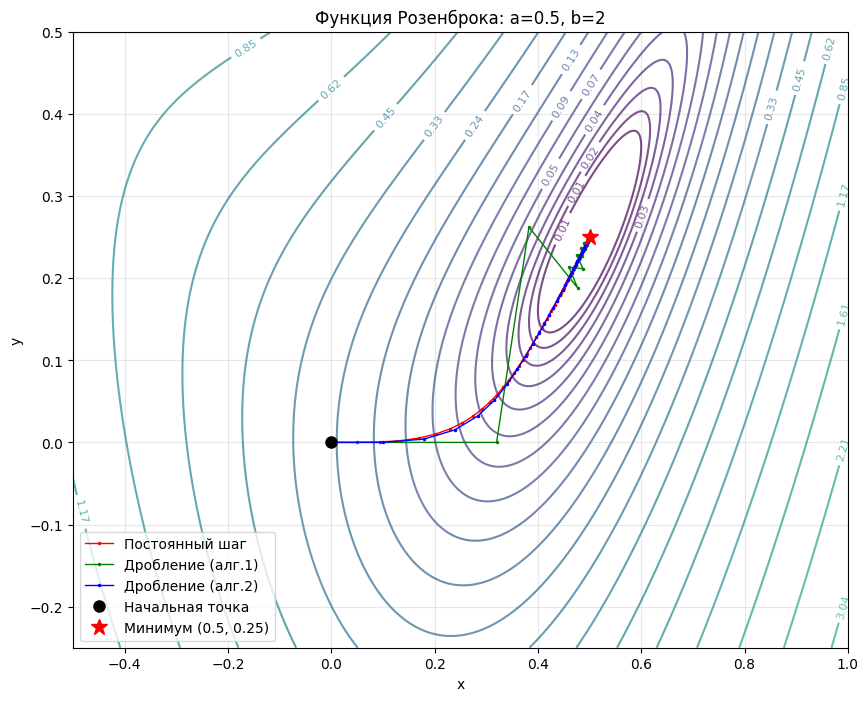

In [136]:
# Визуализация
x_vals = np.linspace(-0.5, 1, 400)
y_vals = np.linspace(-0.25, 0.5, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = rosenbrock(X, Y, a_param, b_param)

plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, levels=np.logspace(-2, 2, 30), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.clabel(contour, inline=True, fontsize=8)

plt.plot(traj_fixed[:, 0], traj_fixed[:, 1], 'r.-', label='Постоянный шаг', linewidth=1, markersize=3)
plt.plot(traj_spl1[:, 0], traj_spl1[:, 1], 'g.-', label='Дробление (алг.1)', linewidth=1, markersize=3)
plt.plot(traj_spl2[:, 0], traj_spl2[:, 1], 'b.-', label='Дробление (алг.2)', linewidth=1, markersize=3)

plt.plot(x_start[0], x_start[1], 'ko', markersize=8, label='Начальная точка')
plt.plot(minimum[0], minimum[1], 'r*', markersize=12, label=f'Минимум ({a_param}, {a_param**2})')

plt.xlim(-0.5, 1)
plt.ylim(-0.25, 0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Функция Розенброка: a={a_param}, b={b_param}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
